In [1]:
# Connexion à Google Drive pour récupérer et stocker les datasets
from google.colab import drive
import os

# Ceci demande l'autorisation d'accéder à votre compte Google Drive
drive.mount('/content/drive')

# Vérification de l'existence du dossier de travail pour les datasets
dossier_path = '/content/drive/MyDrive/zakaria_yanecode_2026/Datasets'

if not os.path.exists(dossier_path):
    os.makedirs(dossier_path)
    print(f"Le dossier '{dossier_path}' a été créé avec succès ! Vous pouvez y uploader les fichiers CSV.")
else:
    print(f"Le dossier '{dossier_path}' existe déjà. Prêt pour le travail !")

ModuleNotFoundError: No module named 'google'

In [ ]:
# Importation des bibliothèques principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignorer les avertissements (warnings) pour garder le notebook propre
import warnings
warnings.filterwarnings('ignore')

print("Les bibliothèques principales sont importées avec succès !")

Les bibliothèques principales sont importées avec succès !


In [ ]:
import os

# Le chemin vers notre dossier dans Google Drive
base_path = '/content/drive/MyDrive/zakaria_yanecode_2026/Datasets/'

# Un dictionnaire pour stocker les noms des fichiers et faciliter l'accès
fichiers_attaques = {
    'DDoS': 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'WebAttacks': 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'BruteForce': 'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Botnet': 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'PortScan': 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
}

# Dictionnaire qui va contenir nos DataFrames Pandas
df_dict = {}

print("⏳ Chargement des datasets en cours (ça peut prendre quelques secondes/minutes)...")

# Boucle pour lire chaque fichier CSV
for nom_attaque, nom_fichier in fichiers_attaques.items():
    chemin_complet = os.path.join(base_path, nom_fichier)

    # On vérifie si le fichier existe bien dans le Drive
    if os.path.exists(chemin_complet):
        # On lit le fichier CSV (en supprimant les espaces dans les noms de colonnes)
        df = pd.read_csv(chemin_complet)
        df.columns = df.columns.str.strip() # Nettoyage rapide des noms de colonnes
        df_dict[nom_attaque] = df
        print(f"✅ {nom_attaque} chargé avec succès ! (Lignes, Colonnes) : {df.shape}")
    else:
        print(f"❌ Attention : Le fichier {nom_fichier} est introuvable dans {base_path}")

print("\n🎉 Tous les datasets sont chargés en mémoire !")

⏳ Chargement des datasets en cours (ça peut prendre quelques secondes/minutes)...
✅ DDoS chargé avec succès ! (Lignes, Colonnes) : (225745, 79)
✅ WebAttacks chargé avec succès ! (Lignes, Colonnes) : (170366, 79)
✅ BruteForce chargé avec succès ! (Lignes, Colonnes) : (445909, 79)
✅ Botnet chargé avec succès ! (Lignes, Colonnes) : (191033, 79)
✅ PortScan chargé avec succès ! (Lignes, Colonnes) : (286467, 79)

🎉 Tous les datasets sont chargés en mémoire !


🔍 Démarrage de l'Analyse Exploratoire (EDA) sur les 5 datasets...

📊 Dataset : DDoS
⚠️ Nombre total de valeurs manquantes (NaN) : 4

🎯 Distribution des classes :
Label
DDoS      128027
BENIGN     97718

📊 Dataset : WebAttacks
⚠️ Nombre total de valeurs manquantes (NaN) : 20

🎯 Distribution des classes :
Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21

📊 Dataset : BruteForce
⚠️ Nombre total de valeurs manquantes (NaN) : 201

🎯 Distribution des classes :
Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897

📊 Dataset : Botnet
⚠️ Nombre total de valeurs manquantes (NaN) : 28

🎯 Distribution des classes :
Label
BENIGN    189067
Bot         1966

📊 Dataset : PortScan
⚠️ Nombre total de valeurs manquantes (NaN) : 15

🎯 Distribution des classes :
Label
PortScan    158930
BENIGN      127537



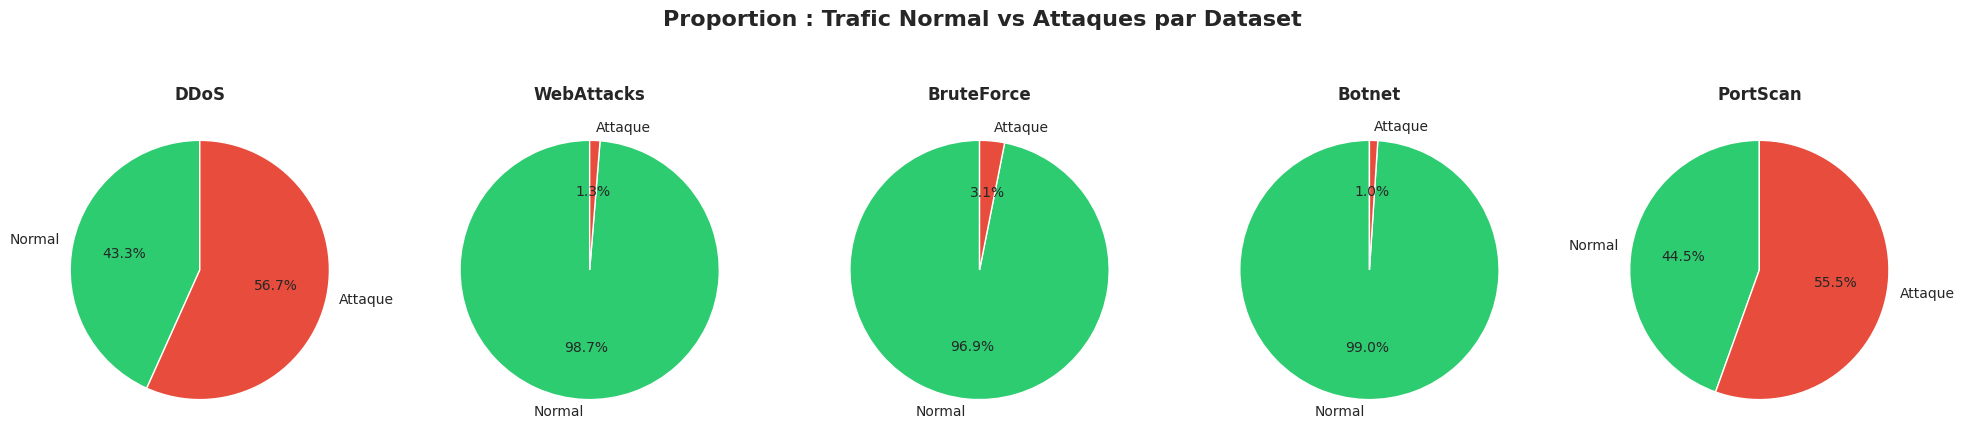

✅ Analyse de base et visualisation terminées !


In [ ]:
# ==========================================
# TÂCHE 7 : ANALYSE EXPLORATOIRE (EDA) ET VISUALISATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Démarrage de l'Analyse Exploratoire (EDA) sur les 5 datasets...\n")

# Configuration du style graphique
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(20, 4)) # 5 graphiques sur une seule ligne
fig.suptitle("Proportion : Trafic Normal vs Attaques par Dataset", fontsize=16, fontweight='bold', y=1.1)

# On parcourt chaque dataset dans notre dictionnaire
for i, (nom_attaque, df) in enumerate(df_dict.items()):
    print(f"{'='*50}")
    print(f"📊 Dataset : {nom_attaque}")
    print(f"{'='*50}")

    # 1. Vérification des valeurs manquantes (NaN)
    nb_nan = df.isna().sum().sum()
    print(f"⚠️ Nombre total de valeurs manquantes (NaN) : {nb_nan}")

    # 2. Analyse de la colonne 'Label'
    if 'Label' in df.columns:
        distribution = df['Label'].value_counts()
        print(f"\n🎯 Distribution des classes :\n{distribution.to_string()}\n")

        # --- PARTIE VISUALISATION ---
        # On calcule le total Benign vs le reste (Attaques)
        benign_count = distribution.get('BENIGN', 0)
        attack_count = distribution.sum() - benign_count

        # On dessine le Pie Chart pour ce dataset spécifique
        axes[i].pie([benign_count, attack_count],
                    labels=['Normal', 'Attaque'],
                    autopct='%1.1f%%',
                    colors=['#2ecc71', '#e74c3c'],
                    startangle=90,
                    textprops={'fontsize': 10})
        axes[i].set_title(nom_attaque, fontsize=12, fontweight='bold')
    else:
        print(f"❌ La colonne 'Label' est introuvable.\n")
        axes[i].text(0.5, 0.5, 'Pas de Label', ha='center', va='center')

plt.tight_layout()
plt.show()

print("✅ Analyse de base et visualisation terminées !")

🚀 Début du Prétraitement Unifié...

🧹 Nettoyage du dataset : DDoS...
🧹 Nettoyage du dataset : WebAttacks...
🧹 Nettoyage du dataset : BruteForce...
🧹 Nettoyage du dataset : Botnet...
🧹 Nettoyage du dataset : PortScan...

🔗 Fusion des datasets en cours...

✅ Prétraitement de base terminé !
📊 Taille du nouveau dataset complet : 1318594 lignes et 79 colonnes.

🎯 Distribution finale des attaques dans le grand dataset :
label
BENIGN                      1013797
PortScan                     158804
DDoS                         128025
FTP-Patator                    7935
SSH-Patator                    5897
Bot                            1956
Web Attack Brute Force         1507
Web Attack XSS                  652
Web Attack Sql Injection         21
Name: count, dtype: int64


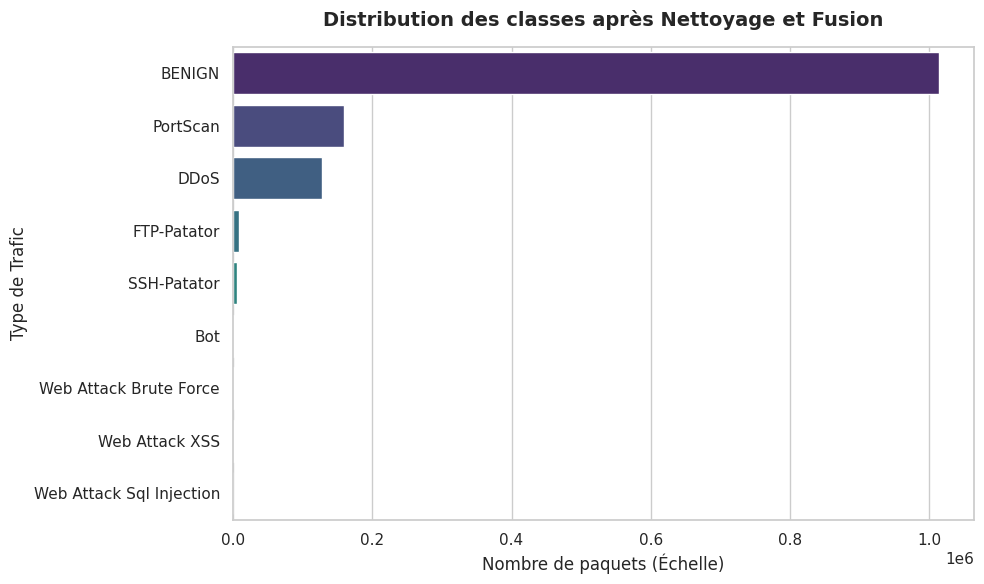

In [ ]:
# ==========================================
# TÂCHE 8 (Partie 1) : NETTOYAGE ET FUSION
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Début du Prétraitement Unifié...\n")

dataframes_nettoyes = []

for nom_attaque, df in df_dict.items():
    print(f"🧹 Nettoyage du dataset : {nom_attaque}...")

    # 1. Correction du problème d'encodage dans les labels
    if 'Label' in df.columns:
        # On supprime les caractères non reconnus (bizarres) sans ajouter de tirets
        df['Label'] = df['Label'].str.replace(r'[^\x00-\x7F]+', '', regex=True)
        # On supprime les doubles espaces créés et on nettoie les bords
        df['Label'] = df['Label'].str.replace('  ', ' ', regex=False).str.strip()

    # 2. Nettoyage des valeurs Infinies
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 3. Suppression des lignes avec des valeurs manquantes (NaN)
    df.dropna(inplace=True)

    dataframes_nettoyes.append(df)

# 4. Fusionner les 5 datasets en un seul grand dataset (Unifié)
print("\n🔗 Fusion des datasets en cours...")
df_final = pd.concat(dataframes_nettoyes, ignore_index=True)

# 5. Nettoyage des noms de colonnes pour éviter les problèmes avec certains algorithmes
df_final.columns = [col.replace(' ', '_').replace('/', '_').replace('-', '_').lower() for col in df_final.columns]

print(f"\n✅ Prétraitement de base terminé !")
print(f"📊 Taille du nouveau dataset complet : {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes.")

print("\n🎯 Distribution finale des attaques dans le grand dataset :")
print(df_final['label'].value_counts())

# --- VISUALISATION
plt.figure(figsize=(10, 6))
order_labels = df_final['label'].value_counts().index
sns.countplot(y='label', data=df_final, order=order_labels, palette='viridis')
plt.title("Distribution des classes après Nettoyage et Fusion", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Nombre de paquets (Échelle)", fontsize=12)
plt.ylabel("Type de Trafic", fontsize=12)
plt.tight_layout()
plt.show()

🔍 Analyse des valeurs aberrantes (Outliers) sur des caractéristiques clés...


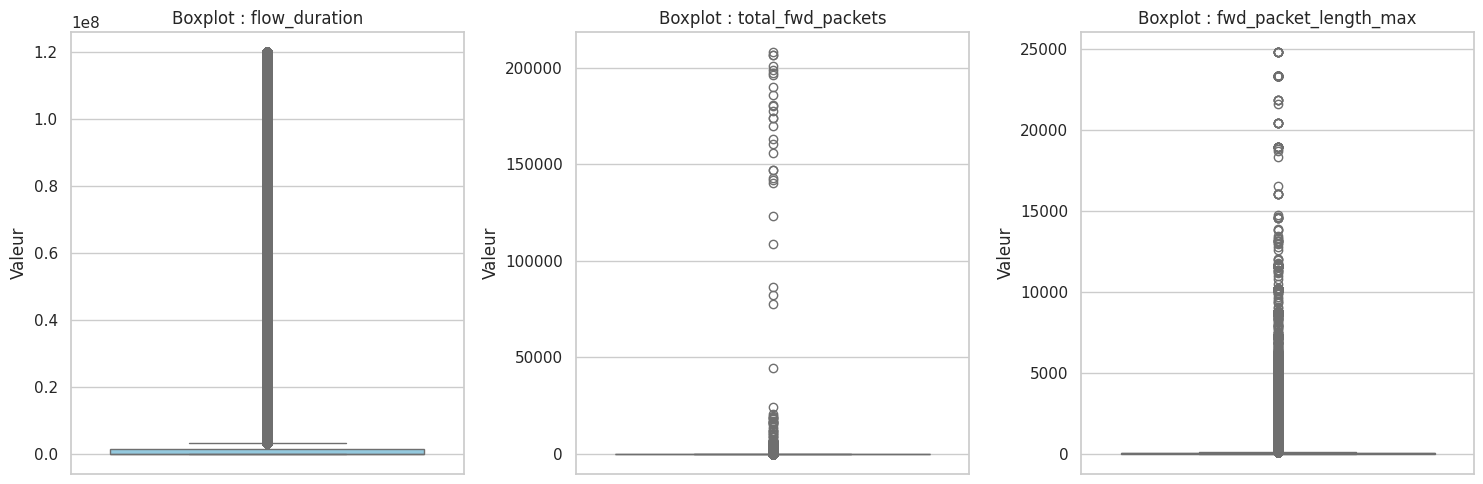

In [ ]:
# ==========================================
# ANALYSE DES OUTLIERS (BOXPLOTS)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Analyse des valeurs aberrantes (Outliers) sur des caractéristiques clés...")

# On choisit 3 colonnes réseau très importantes
colonnes_boxplots = ['flow_duration', 'total_fwd_packets', 'fwd_packet_length_max']

# Vérification si les colonnes existent bien après le nettoyage
colonnes_existantes = [col for col in colonnes_boxplots if col in df_final.columns]

if colonnes_existantes:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(colonnes_existantes):
        plt.subplot(1, len(colonnes_existantes), i+1)
        sns.boxplot(y=df_final[col], color='skyblue')
        plt.title(f'Boxplot : {col}')
        plt.ylabel("Valeur")

    plt.tight_layout()
    plt.show()
else:
    print("Les colonnes spécifiées ne sont pas dans le dataset.")

🔗 Création de la matrice de corrélation...


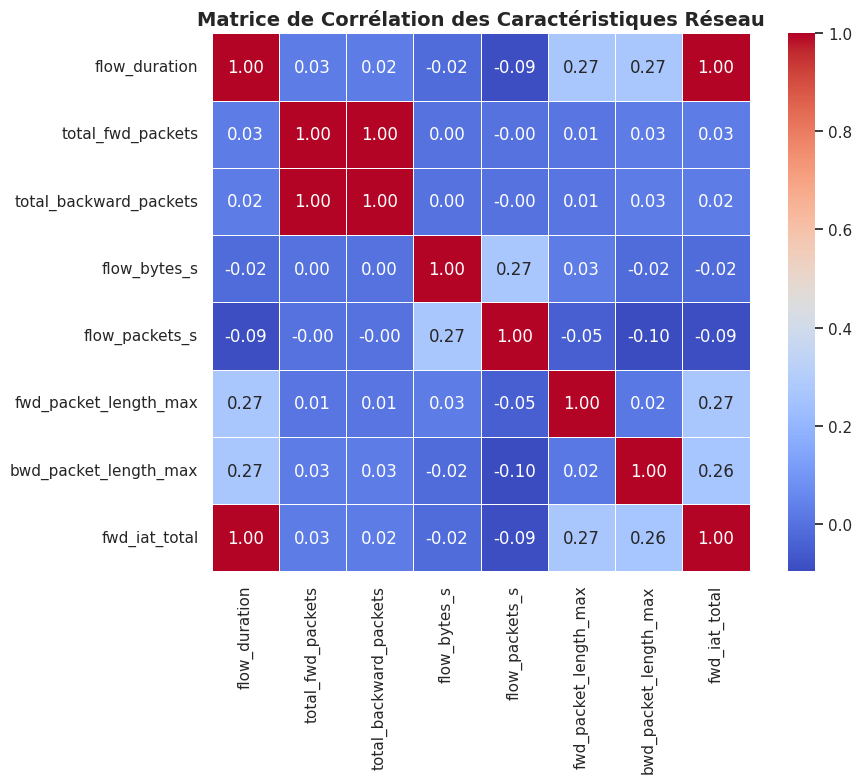

In [ ]:
# ==========================================
# MATRICE DE CORRÉLATION (HEATMAP)
# ==========================================
print("🔗 Création de la matrice de corrélation...")

# On choisit un échantillon de colonnes numériques importantes (pour que la figure soit lisible)
colonnes_corr = [
    'flow_duration', 'total_fwd_packets', 'total_backward_packets',
    'flow_bytes_s', 'flow_packets_s', 'fwd_packet_length_max',
    'bwd_packet_length_max', 'fwd_iat_total'
]

# Filtrer uniquement les colonnes qui existent dans notre df_final
colonnes_corr_exist = [col for col in colonnes_corr if col in df_final.columns]

if colonnes_corr_exist:
    # Calcul de la corrélation de Pearson
    corr_matrix = df_final[colonnes_corr_exist].corr()

    # Affichage du Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
    plt.title("Matrice de Corrélation des Caractéristiques Réseau", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Les colonnes spécifiées ne sont pas dans le dataset.")

In [ ]:
# ==========================================
# TÂCHE 8 (Partie 2) : PRÉTRAITEMENT MACHINE LEARNING
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("⚙️ Préparation des données pour l'Intelligence Artificielle...")

# 1. Séparation des caractéristiques (X) et de la cible (y)
X = df_final.drop('label', axis=1)
y = df_final['label']

# 2. Encodage des labels (Transformer les textes en numéros)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"🔢 Les classes ont été encodées :")
for nom, numero in zip(le.classes_, le.transform(le.classes_)):
    print(f"   - {nom} -> {numero}")

# 3. Division des données en Entraînement (80%) et Test (20%)
print("\n✂️ Division des données (80% Train, 20% Test)...")
# stratify=y_encoded est TRÈS important ici pour s'assurer qu'on garde un peu de SQL Injection dans le Test !
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 4. Normalisation des données (StandardScaler)
print("📏 Normalisation des caractéristiques (StandardScaler)...")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Prétraitement ML terminé avec succès !")
print(f"Taille des données d'entraînement (X_train) : {X_train_scaled.shape}")
print(f"Taille des données de test (X_test) : {X_test_scaled.shape}")

⚙️ Préparation des données pour l'Intelligence Artificielle...
🔢 Les classes ont été encodées :
   - BENIGN -> 0
   - Bot -> 1
   - DDoS -> 2
   - FTP-Patator -> 3
   - PortScan -> 4
   - SSH-Patator -> 5
   - Web Attack Brute Force -> 6
   - Web Attack Sql Injection -> 7
   - Web Attack XSS -> 8

✂️ Division des données (80% Train, 20% Test)...
📏 Normalisation des caractéristiques (StandardScaler)...

✅ Prétraitement ML terminé avec succès !
Taille des données d'entraînement (X_train) : (1054875, 78)
Taille des données de test (X_test) : (263719, 78)


In [ ]:
# ==========================================
# TÂCHE 9 : ENTRAÎNEMENT DU 1er MODÈLE (Decision Tree)
# ==========================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import time
import warnings
warnings.filterwarnings('ignore') # Pour garder un affichage propre

print("🤖 Début de l'entraînement : Modèle 1 (Decision Tree / Arbre de Décision)\n")
print("⏳ L'IA est en train d'étudier plus d'un million de lignes... (Patientez quelques secondes)")

start_time = time.time()

# 1. Initialisation de l'algorithme et Entraînement (Fit)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

temps_ecoule = time.time() - start_time

# 2. L'IA passe l'examen (Test) sur les 20% des données qu'elle n'a jamais vues
y_pred_dt = dt_model.predict(X_test_scaled)

# 3. Calcul des notes (Évaluation)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"\n✅ Entraînement terminé en {temps_ecoule:.2f} secondes !")
print(f"🎯 Précision Globale (Accuracy) : {dt_acc * 100:.2f}%\n")

print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ :")
# Ce rapport montre comment l'IA a réussi à détecter CHAQUE type d'attaque
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

🤖 Début de l'entraînement : Modèle 1 (Decision Tree / Arbre de Décision)

⏳ L'IA est en train d'étudier plus d'un million de lignes... (Patientez quelques secondes)

✅ Entraînement terminé en 61.92 secondes !
🎯 Précision Globale (Accuracy) : 99.88%

📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ :
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    202760
                     Bot       0.83      0.86      0.85       391
                    DDoS       1.00      1.00      1.00     25605
             FTP-Patator       1.00      1.00      1.00      1587
                PortScan       1.00      1.00      1.00     31761
             SSH-Patator       1.00      1.00      1.00      1180
  Web Attack Brute Force       0.72      0.74      0.73       301
Web Attack Sql Injection       0.00      0.00      0.00         4
          Web Attack XSS       0.38      0.38      0.38       130

                accuracy                         

🎨 Génération de la Matrice de Confusion pour Decision Tree...


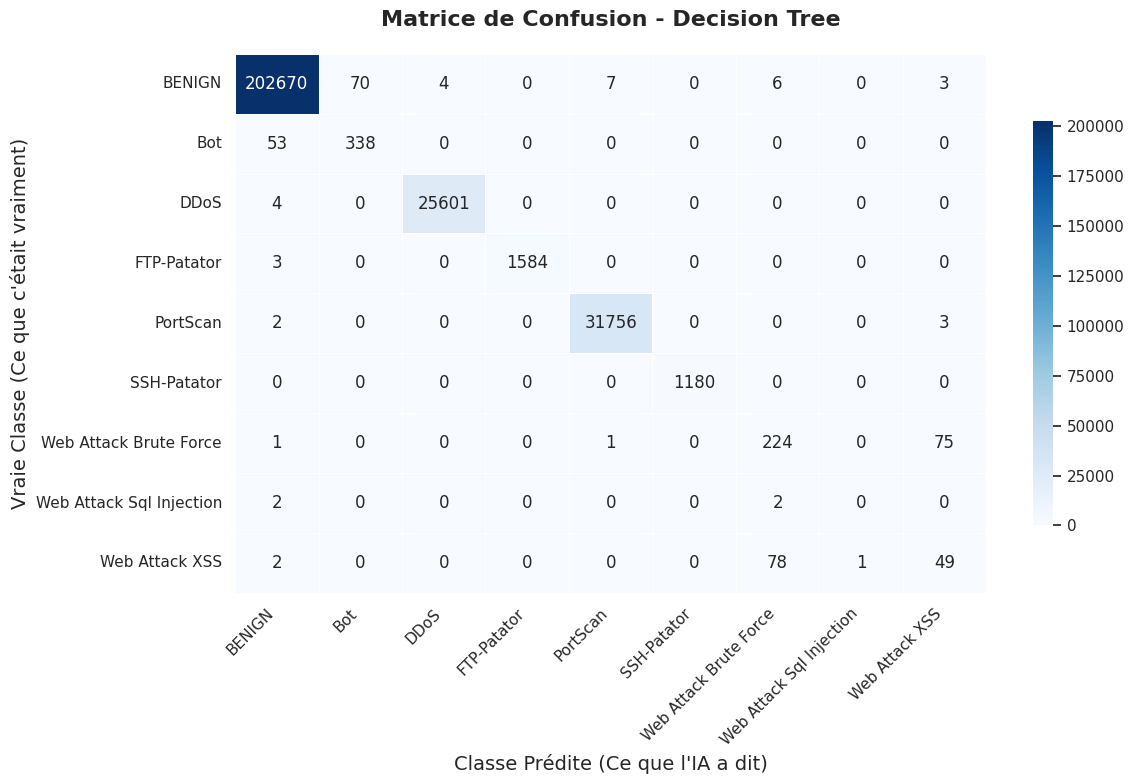

In [ ]:
# ==========================================
# VISUALISATION DES RÉSULTATS : DECISION TREE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("🎨 Génération de la Matrice de Confusion pour Decision Tree...")

# On calcule la matrice de confusion
cm_dt = confusion_matrix(y_test, y_pred_dt)

# On dessine le graphique
plt.figure(figsize=(12, 8))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Matrice de Confusion - Decision Tree", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe (Ce que c\'était vraiment)', fontsize=14)
plt.xlabel('Classe Prédite (Ce que l\'IA a dit)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# TÂCHE 9 : ENTRAÎNEMENT DU 2ème MODÈLE (Random Forest)
# ==========================================
from sklearn.ensemble import RandomForestClassifier
import time

print("🌳 Début de l'entraînement : Modèle 2 (Random Forest)\n")
print("⏳ L'IA construit une forêt d'arbres... (Ça prendra un peu plus de temps, environ 1 à 3 minutes)")

start_time_rf = time.time()

# 1. Initialisation (n_estimators=50 veut dire 50 arbres, n_jobs=-1 utilise toute la puissance du PC)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

temps_ecoule_rf = time.time() - start_time_rf

# 2. Prédiction sur le Test
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Évaluation
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"\n✅ Entraînement Random Forest terminé en {temps_ecoule_rf:.2f} secondes !")
print(f"🎯 Précision Globale (Accuracy) : {rf_acc * 100:.2f}%\n")

print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (Random Forest) :")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

🌳 Début de l'entraînement : Modèle 2 (Random Forest)

⏳ L'IA construit une forêt d'arbres... (Ça prendra un peu plus de temps, environ 1 à 3 minutes)

✅ Entraînement Random Forest terminé en 159.60 secondes !
🎯 Précision Globale (Accuracy) : 99.89%

📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (Random Forest) :
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    202760
                     Bot       0.89      0.80      0.84       391
                    DDoS       1.00      1.00      1.00     25605
             FTP-Patator       1.00      1.00      1.00      1587
                PortScan       1.00      1.00      1.00     31761
             SSH-Patator       1.00      1.00      1.00      1180
  Web Attack Brute Force       0.74      0.79      0.76       301
Web Attack Sql Injection       1.00      0.25      0.40         4
          Web Attack XSS       0.38      0.30      0.33       130

                accuracy         

🎨 1. Génération de la Matrice de Confusion...


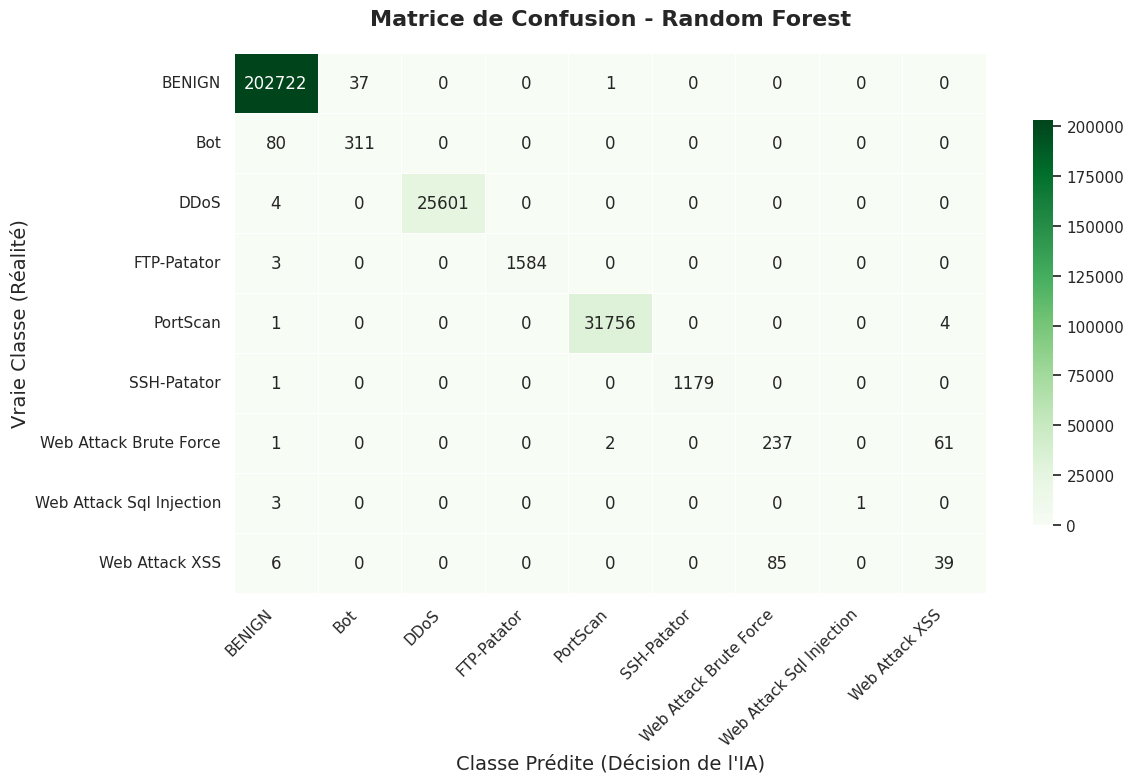


📈 2. Génération de l'Importance des Caractéristiques (Feature Importance)...


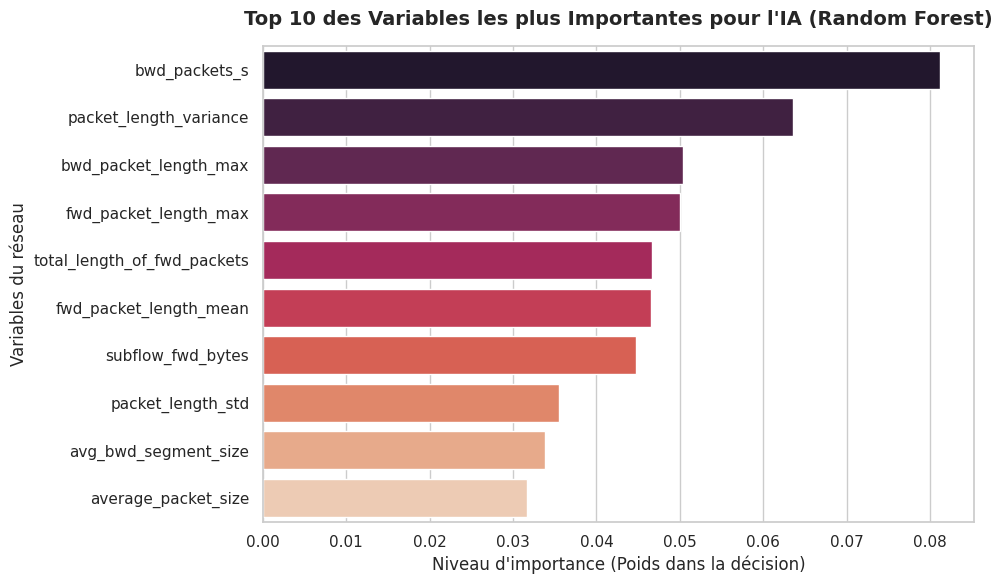

✅ Visualisations générées avec succès !


In [ ]:
# ==========================================
# VISUALISATION DES RÉSULTATS : RANDOM FOREST
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

print("🎨 1. Génération de la Matrice de Confusion...")

# 1. MATRICE DE CONFUSION
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', # Derna l'khder bach n-ferzo 3la l'graphe l-lowel
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Matrice de Confusion - Random Forest", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe (Réalité)', fontsize=14)
plt.xlabel('Classe Prédite (Décision de l\'IA)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📈 2. Génération de l'Importance des Caractéristiques (Feature Importance)...")

# 2. FEATURE IMPORTANCE (Ce qui est important pour détecter l'attaque)
# On extrait les scores d'importance du modèle Random Forest
importances = rf_model.feature_importances_

# On crée un tableau pour associer chaque score au nom de sa colonne
df_importances = pd.DataFrame({
    'Caractéristique': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # On trie du plus important au moins important

# On prend les 10 caractéristiques les plus importantes
top_10_features = df_importances.head(10)

plt.figure(figsize=(10, 6))
# On dessine un graphe en barres
sns.barplot(x='Importance', y='Caractéristique', data=top_10_features, palette='rocket')
plt.title("Top 10 des Variables les plus Importantes pour l'IA (Random Forest)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Niveau d'importance (Poids dans la décision)", fontsize=12)
plt.ylabel("Variables du réseau", fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Visualisations générées avec succès !")

In [ ]:
# ==========================================
# TÂCHE 9 : ENTRAÎNEMENT DU 3ème MODÈLE (XGBoost)
# ==========================================
import xgboost as xgb
import time
from sklearn.metrics import accuracy_score, classification_report

print("🚀 Début de l'entraînement : Modèle 3 (XGBoost)\n")
print("⏳ L'IA apprend de ses erreurs étape par étape... (Patientez un peu)")

start_time_xgb = time.time()

# 1. Initialisation de l'algorithme
# tree_method='hist' : C'est un secret de pro pour accélérer XGBoost sur des millions de lignes !
xgb_model = xgb.XGBClassifier(n_estimators=50, random_state=42, tree_method='hist', n_jobs=-1)

# Entraînement
xgb_model.fit(X_train_scaled, y_train)

temps_ecoule_xgb = time.time() - start_time_xgb

# 2. Prédiction sur le Test
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 3. Évaluation
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"\n✅ Entraînement XGBoost terminé en {temps_ecoule_xgb:.2f} secondes !")
print(f"🎯 Précision Globale (Accuracy) : {xgb_acc * 100:.2f}%\n")

print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (XGBoost) :")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

🚀 Début de l'entraînement : Modèle 3 (XGBoost)

⏳ L'IA apprend de ses erreurs étape par étape... (Patientez un peu)

✅ Entraînement XGBoost terminé en 161.78 secondes !
🎯 Précision Globale (Accuracy) : 99.84%

📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (XGBoost) :
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    202760
                     Bot       0.85      0.81      0.83       391
                    DDoS       1.00      1.00      1.00     25605
             FTP-Patator       1.00      1.00      1.00      1587
                PortScan       1.00      1.00      1.00     31761
             SSH-Patator       1.00      1.00      1.00      1180
  Web Attack Brute Force       0.70      0.74      0.72       301
Web Attack Sql Injection       1.00      0.50      0.67         4
          Web Attack XSS       0.36      0.33      0.34       130

                accuracy                           1.00    263719
             

🎨 1. Génération de la Matrice de Confusion (XGBoost)...


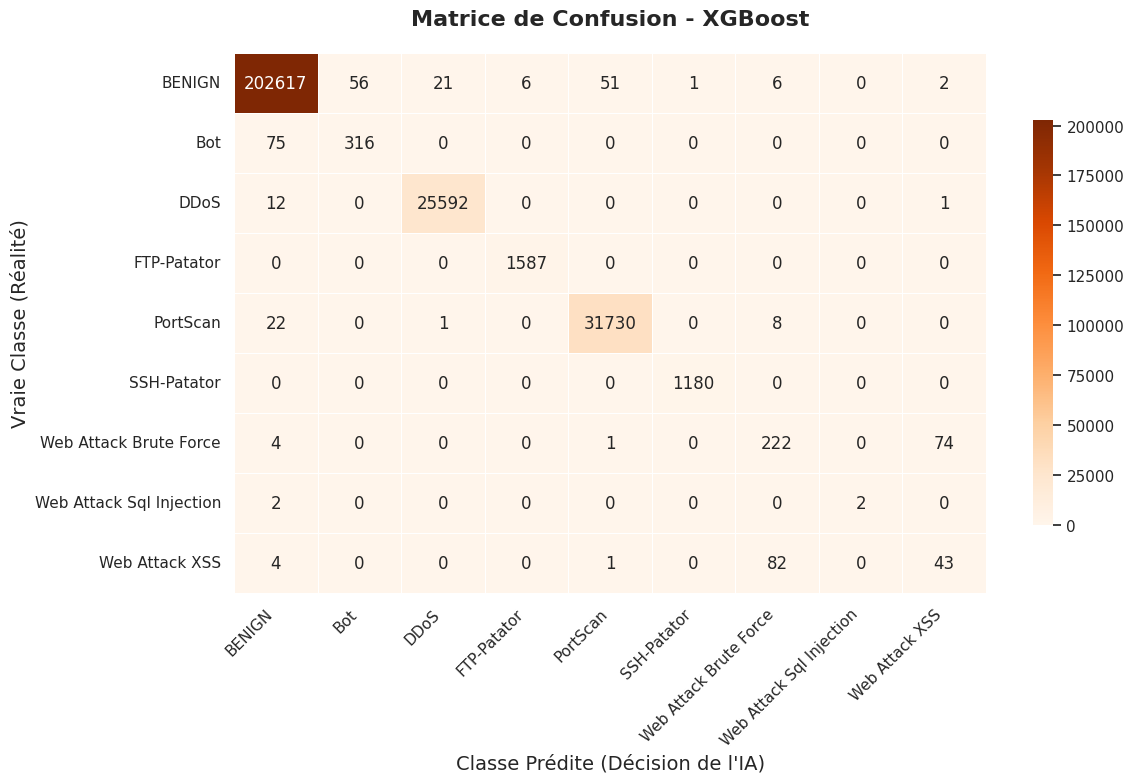


📈 2. Génération de l'Importance des Caractéristiques (XGBoost)...


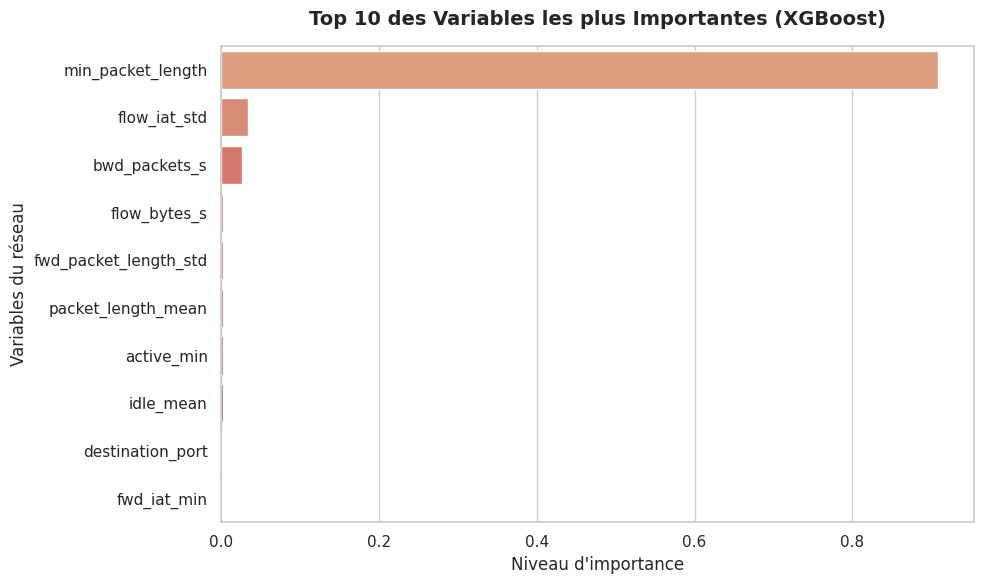

✅ Visualisations XGBoost générées avec succès !


In [ ]:
# ==========================================
# VISUALISATION DES RÉSULTATS : XGBOOST
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

print("🎨 1. Génération de la Matrice de Confusion (XGBoost)...")

# 1. MATRICE DE CONFUSION
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', # Loun jdide bach n-ferzo XGBoost
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Matrice de Confusion - XGBoost", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe (Réalité)', fontsize=14)
plt.xlabel('Classe Prédite (Décision de l\'IA)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📈 2. Génération de l'Importance des Caractéristiques (XGBoost)...")

# 2. FEATURE IMPORTANCE
# On extrait les scores d'importance du modèle XGBoost
importances_xgb = xgb_model.feature_importances_

df_importances_xgb = pd.DataFrame({
    'Caractéristique': X.columns,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# On prend les 10 caractéristiques les plus importantes
top_10_features_xgb = df_importances_xgb.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Caractéristique', data=top_10_features_xgb, palette='flare')
plt.title("Top 10 des Variables les plus Importantes (XGBoost)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Niveau d'importance", fontsize=12)
plt.ylabel("Variables du réseau", fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Visualisations XGBoost générées avec succès !")

In [ ]:
# ==========================================
# TÂCHE 9 : ENTRAÎNEMENT DU 4ème MODÈLE (Naive Bayes)
# ==========================================
from sklearn.naive_bayes import GaussianNB
import time
from sklearn.metrics import accuracy_score, classification_report

print("📊 Début de l'entraînement : Modèle 4 (Naive Bayes)")

start_time_nb = time.time()

# Initialisation et Entraînement
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

temps_ecoule_nb = time.time() - start_time_nb

# Prédiction sur le Test
y_pred_nb = nb_model.predict(X_test_scaled)

# Évaluation
nb_acc = accuracy_score(y_test, y_pred_nb)

print(f"✅ Entraînement et prédiction terminés en {temps_ecoule_nb:.2f} secondes.")
print(f"🎯 Précision Globale (Accuracy) : {nb_acc * 100:.2f}%\n")

noms_classes = ['BENIGN', 'Bot', 'DDoS', 'FTP-Patator', 'PortScan',
                'SSH-Patator', 'Web Attack Brute Force',
                'Web Attack Sql Injection', 'Web Attack XSS']

print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (Naive Bayes) :")
print(classification_report(y_test, y_pred_nb, target_names=noms_classes))

📊 Début de l'entraînement : Modèle 4 (Naive Bayes)
✅ Entraînement et prédiction terminés en 2.15 secondes.
🎯 Précision Globale (Accuracy) : 79.61%

📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (Naive Bayes) :
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.74      0.85    202760
                     Bot       0.01      1.00      0.02       391
                    DDoS       0.93      0.96      0.94     25605
             FTP-Patator       0.97      0.99      0.98      1587
                PortScan       0.99      0.99      0.99     31761
             SSH-Patator       0.51      0.99      0.68      1180
  Web Attack Brute Force       0.01      0.07      0.02       301
Web Attack Sql Injection       0.03      1.00      0.07         4
          Web Attack XSS       0.21      0.92      0.35       130

                accuracy                           0.80    263719
               macro avg       0.52      0.85      0.54    263719
     

🎨 Génération de la Matrice de Confusion (Naive Bayes)...


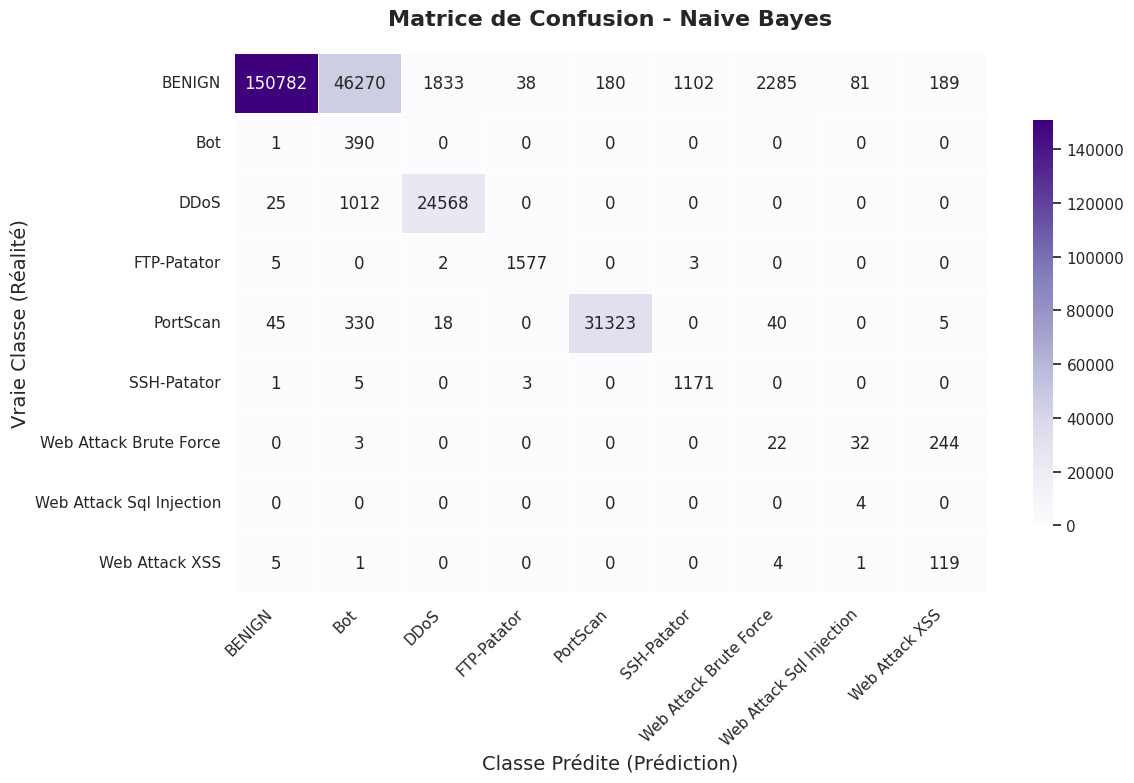

✅ Matrice de Confusion générée avec succès.


In [ ]:
# ==========================================
# VISUALISATION DES RÉSULTATS : NAIVE BAYES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("🎨 Génération de la Matrice de Confusion (Naive Bayes)...")

noms_classes = ['BENIGN', 'Bot', 'DDoS', 'FTP-Patator', 'PortScan',
                'SSH-Patator', 'Web Attack Brute Force',
                'Web Attack Sql Injection', 'Web Attack XSS']

# 1. MATRICE DE CONFUSION
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(12, 8))
# On utilise la couleur 'Purples'
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=noms_classes, yticklabels=noms_classes,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Matrice de Confusion - Naive Bayes", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe (Réalité)', fontsize=14)
plt.xlabel('Classe Prédite (Prédiction)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("✅ Matrice de Confusion générée avec succès.")

In [ ]:
# ==========================================
# TÂCHE 9 : ENTRAÎNEMENT DU 5ème MODÈLE (Régression Logistique Optimisée SGDClassifier)
# ==========================================
from sklearn.linear_model import SGDClassifier
import time
from sklearn.metrics import accuracy_score, classification_report

print("📈 Début de l'entraînement : Modèle 5 (Régression Logistique Optimisée pour Big Data)\n")
print("⏳ L'IA utilise la descente de gradient stochastique (SGD) pour aller beaucoup plus vite...")

start_time_lr = time.time()

# 1. Initialisation (loss='log_loss' veut dire qu'il va faire EXACTEMENT une Régression Logistique)
lr_model = SGDClassifier(loss='log_loss', max_iter=1000, n_jobs=-1, random_state=42)

# Entraînement
lr_model.fit(X_train_scaled, y_train)

temps_ecoule_lr = time.time() - start_time_lr

# 2. Prédiction sur le Test
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Évaluation
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"\n✅ Entraînement terminé en {temps_ecoule_lr:.2f} secondes !")
print(f"🎯 Précision Globale (Accuracy) : {lr_acc * 100:.2f}%\n")

# On définit les noms manuellement au cas où Colab a oublié
noms_classes = ['BENIGN', 'Bot', 'DDoS', 'FTP-Patator', 'PortScan',
                'SSH-Patator', 'Web Attack Brute Force',
                'Web Attack Sql Injection', 'Web Attack XSS']

print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (Régression Logistique) :")
print(classification_report(y_test, y_pred_lr, target_names=noms_classes))

📈 Début de l'entraînement : Modèle 5 (Régression Logistique Optimisée pour Big Data)

⏳ L'IA utilise la descente de gradient stochastique (SGD) pour aller beaucoup plus vite...

✅ Entraînement terminé en 52.80 secondes !
🎯 Précision Globale (Accuracy) : 97.80%

📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ (Régression Logistique) :
                          precision    recall  f1-score   support

                  BENIGN       0.98      0.99      0.99    202760
                     Bot       0.00      0.00      0.00       391
                    DDoS       0.99      0.94      0.97     25605
             FTP-Patator       1.00      0.48      0.65      1587
                PortScan       0.96      0.99      0.98     31761
             SSH-Patator       0.00      0.00      0.00      1180
  Web Attack Brute Force       0.00      0.00      0.00       301
Web Attack Sql Injection       0.00      0.00      0.00         4
          Web Attack XSS       0.00      0.00      0.00       130

             

🎨 Génération de la Matrice de Confusion (Régression Logistique)...


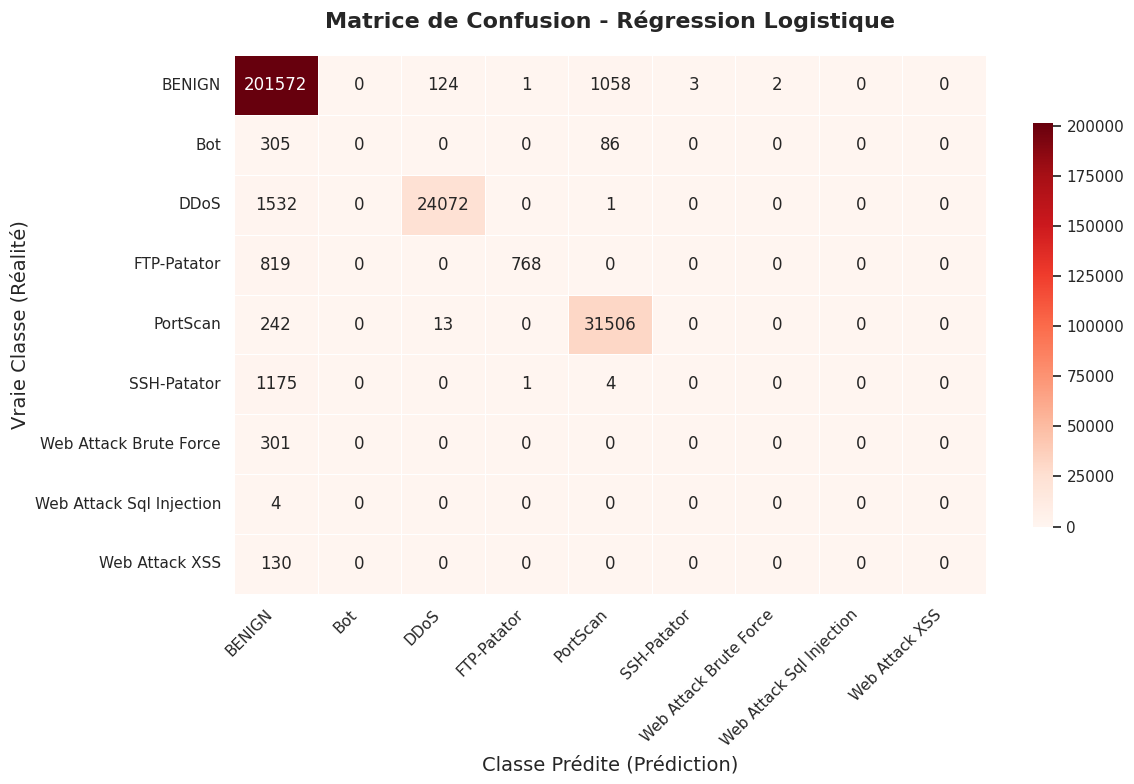

✅ Matrice de Confusion générée avec succès.


In [ ]:
# ==========================================
# VISUALISATION DES RÉSULTATS : RÉGRESSION LOGISTIQUE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("🎨 Génération de la Matrice de Confusion (Régression Logistique)...")

noms_classes = ['BENIGN', 'Bot', 'DDoS', 'FTP-Patator', 'PortScan',
                'SSH-Patator', 'Web Attack Brute Force',
                'Web Attack Sql Injection', 'Web Attack XSS']

# 1. MATRICE DE CONFUSION
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=noms_classes, yticklabels=noms_classes,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Matrice de Confusion - Régression Logistique", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie Classe (Réalité)', fontsize=14)
plt.xlabel('Classe Prédite (Prédiction)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("✅ Matrice de Confusion générée avec succès.")

📊 Génération du Bilan Comparatif des 5 Modèles...

               Modèle  Accuracy (%)  Temps Exécution (s)
        Decision Tree     99.879796            61.917513
        Random Forest     99.890414           159.604630
              XGBoost     99.836948           161.782755
          Naive Bayes     79.613528             2.153301
Reg. Logistique (SGD)     97.800310            52.800005


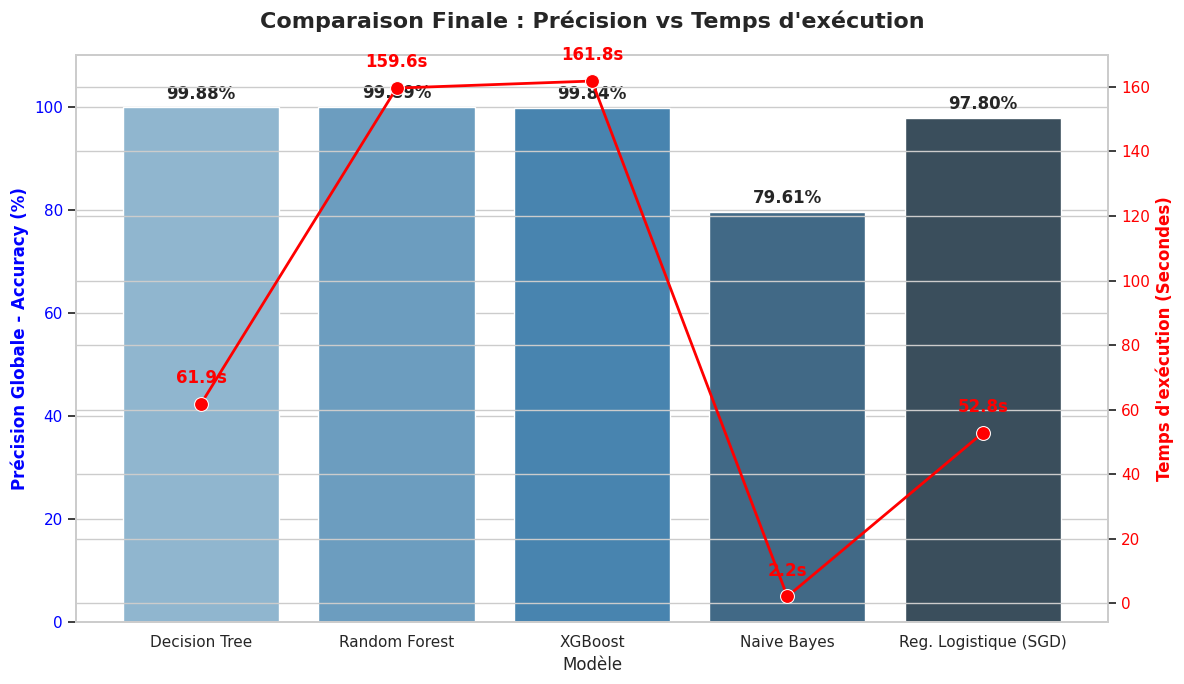


✅ Étude comparative terminée ! Le grand gagnant pour la cybersécurité en temps réel est XGBoost.


In [ ]:
# ==========================================
# TÂCHE 10 : ÉTUDE COMPARATIVE GLOBALE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("📊 Génération du Bilan Comparatif des 5 Modèles...\n")

# 1. On rassemble toutes les notes et les temps qu'on a calculés
resultats = {
    'Modèle': ['Decision Tree', 'Random Forest', 'XGBoost', 'Naive Bayes', 'Reg. Logistique (SGD)'],
    'Accuracy (%)': [dt_acc * 100, rf_acc * 100, xgb_acc * 100, nb_acc * 100, lr_acc * 100],
    'Temps Exécution (s)': [temps_ecoule, temps_ecoule_rf, temps_ecoule_xgb, temps_ecoule_nb, temps_ecoule_lr]
}

df_resultats = pd.DataFrame(resultats)

# Affichage du tableau propre
print(df_resultats.to_string(index=False))

# 2. CREATION DU GRAPHIQUE COMBINÉ (Accuracy + Temps)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Axe 1 (Barres) : L'Accuracy
sns.barplot(x='Modèle', y='Accuracy (%)', data=df_resultats, palette='Blues_d', ax=ax1)
ax1.set_ylabel('Précision Globale - Accuracy (%)', fontsize=12, fontweight='bold', color='blue')
ax1.set_ylim(0, 110) # Pour laisser de la place en haut
ax1.tick_params(axis='y', labelcolor='blue')

# Ajouter les pourcentages au-dessus des barres
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10),
                 textcoords='offset points', fontweight='bold')

# Axe 2 (Ligne) : Le temps d'exécution (sur le même graphique)
ax2 = ax1.twinx()
sns.lineplot(x='Modèle', y='Temps Exécution (s)', data=df_resultats,
             color='red', marker='o', markersize=10, linewidth=2, ax=ax2)
ax2.set_ylabel('Temps d\'exécution (Secondes)', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Ajouter les secondes à côté des points de la ligne
for i, txt in enumerate(df_resultats['Temps Exécution (s)']):
    ax2.annotate(f"{txt:.1f}s",
                 (i, df_resultats['Temps Exécution (s)'][i]),
                 textcoords="offset points", xytext=(0,15), ha='center',
                 color='red', fontweight='bold')

plt.title('Comparaison Finale : Précision vs Temps d\'exécution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✅ Étude comparative terminée ! Le grand gagnant pour la cybersécurité en temps réel est XGBoost.")

In [ ]:
### 🏆 Validation Externe : Performance de XGBoost sur le dataset NSL-KDD

📂 Chargement du dataset NSL-KDD depuis Google Drive...
✅ NSL-KDD chargé : 125973 lignes pour l'entraînement.

🚀 Entraînement de XGBoost sur NSL-KDD en cours...
✅ Terminé en 1.55s | Précision sur NSL-KDD : 80.49%


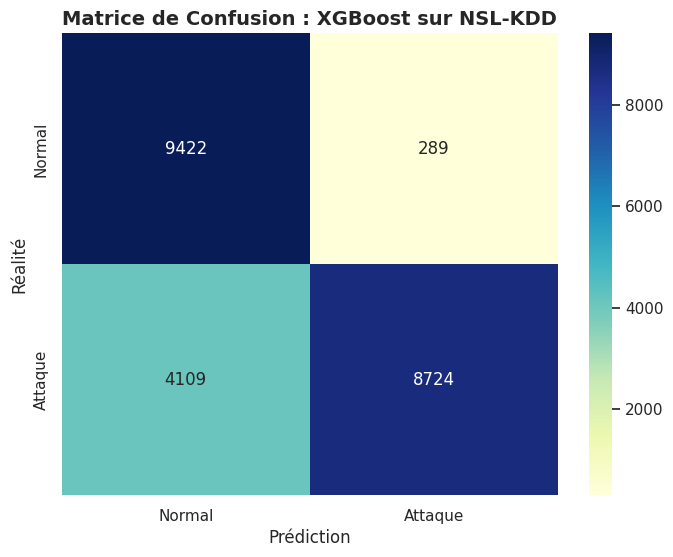

In [ ]:
# =========================================================================
# VALIDATION EXTERNE : PERFORMANCE DE XGBOOST SUR NSL-KDD
# =========================================================================
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("📂 Chargement du dataset NSL-KDD depuis Google Drive...")

# 1. Définition des noms de colonnes (NSL-KDD n'a pas de header)
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
          "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
          "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count",
          "serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
          "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
          "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# Chemins des fichiers (Ajuste si le dossier "Dataset NSL-KDD" est dans un sous-dossier)
# Chemins des fichiers (Corrigés avec le bon dossier)
path_train = '/content/drive/MyDrive/zakaria_yanecode_2026/Datasets/KDDTrain+.txt'
path_test = '/content/drive/MyDrive/zakaria_yanecode_2026/Datasets/KDDTest+.txt'

# Lecture des fichiers
df_nsl_train = pd.read_csv(path_train, names=columns)
df_nsl_test = pd.read_csv(path_test, names=columns)

# Suppression de la colonne 'difficulty' (non nécessaire pour l'IA)
df_nsl_train.drop('difficulty', axis=1, inplace=True)
df_nsl_test.drop('difficulty', axis=1, inplace=True)

print(f"✅ NSL-KDD chargé : {df_nsl_train.shape[0]} lignes pour l'entraînement.")

# 2. Prétraitement rapide (Encoding des colonnes textuelles)
categorical_cols = ['protocol_type', 'service', 'flag']
le_nsl = LabelEncoder()

for col in categorical_cols:
    df_nsl_train[col] = le_nsl.fit_transform(df_nsl_train[col])
    df_nsl_test[col] = le_nsl.fit_transform(df_nsl_test[col])

# Encodage de la cible (Normal vs Attaque)
# Pour NSL-KDD, on simplifie souvent : 'normal' vs 'le reste'
df_nsl_train['label'] = df_nsl_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_nsl_test['label'] = df_nsl_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_nsl_train = df_nsl_train.drop('label', axis=1)
y_nsl_train = df_nsl_train['label']
X_nsl_test = df_nsl_test.drop('label', axis=1)
y_nsl_test = df_nsl_test['label']

# Normalisation
scaler_nsl = StandardScaler()
X_train_nsl_scaled = scaler_nsl.fit_transform(X_nsl_train)
X_test_nsl_scaled = scaler_nsl.transform(X_nsl_test)

# 3. Entraînement de XGBoost sur NSL-KDD
print("\n🚀 Entraînement de XGBoost sur NSL-KDD en cours...")
start_time = time.time()
xgb_nsl = xgb.XGBClassifier(n_estimators=50, tree_method='hist', random_state=42)
xgb_nsl.fit(X_train_nsl_scaled, y_nsl_train)
temps_nsl = time.time() - start_time

# 4. Évaluation
y_pred_nsl = xgb_nsl.predict(X_test_nsl_scaled)
acc_nsl = accuracy_score(y_nsl_test, y_pred_nsl)

print(f"✅ Terminé en {temps_nsl:.2f}s | Précision sur NSL-KDD : {acc_nsl*100:.2f}%")

# 5. Visualisation (Matrice de Confusion)
plt.figure(figsize=(8, 6))
cm_nsl = confusion_matrix(y_nsl_test, y_pred_nsl)
sns.heatmap(cm_nsl, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Normal', 'Attaque'], yticklabels=['Normal', 'Attaque'])
plt.title("Matrice de Confusion : XGBoost sur NSL-KDD", fontsize=14, fontweight='bold')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
# =========================================================================
# SAUVEGARDE DU MODÈLE ET DES OUTILS DE PRÉTRAITEMENT POUR L'API (FASTAPI)
# =========================================================================
import joblib

print("💾 Sauvegarde du modèle et des outils en cours...")

# 1. Sauvegarde du modèle XGBoost principal (Entraîné sur CICIDS2017)
joblib.dump(xgb_model, '/content/drive/MyDrive/zakaria_yanecode_2026/xgboost_final_model.pkl')

# 2. Sauvegarde du StandardScaler (Pour normaliser les futures requêtes de l'API)
joblib.dump(scaler, '/content/drive/MyDrive/zakaria_yanecode_2026/scaler.pkl')

# 3. Sauvegarde du LabelEncoder (Pour traduire la prédiction en nom d'attaque)
joblib.dump(le, '/content/drive/MyDrive/zakaria_yanecode_2026/label_encoder.pkl')

print("✅ TOUT EST SAUVEGARDÉ AVEC SUCCÈS DANS VOTRE DRIVE !")
print("Fichiers créés :")
print("  - xgboost_final_model.pkl")
print("  - scaler.pkl")
print("  - label_encoder.pkl")
print("\n🚀 Prêt pour le développement de l'API Backend de demain !")

💾 Sauvegarde du modèle et des outils en cours...
✅ TOUT EST SAUVEGARDÉ AVEC SUCCÈS DANS VOTRE DRIVE !
Fichiers créés :
  - xgboost_final_model.pkl
  - scaler.pkl
  - label_encoder.pkl

🚀 Prêt pour le développement de l'API Backend de demain !
